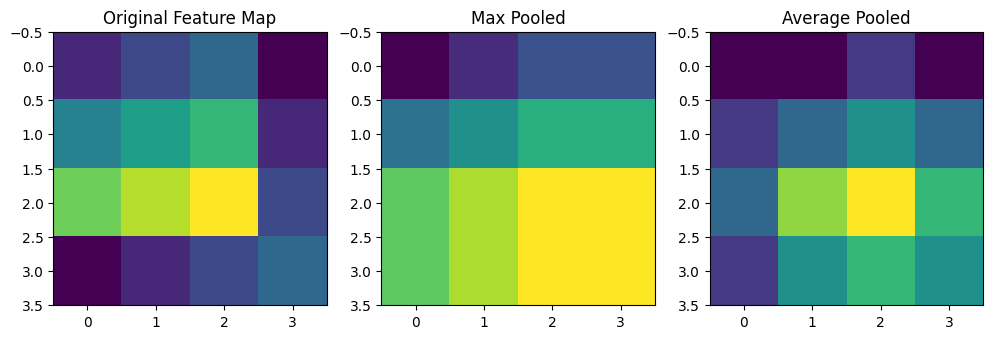


 ############################## 

Max Pooling Tensor:
 [[5. 6.]
 [8. 9.]]
Average Pooled Tensor:
[[3.  2.5]
 [4.  4. ]]

 ############################## 

Max Pooled Tensor:
 [[5. 6.]
 [8. 9.]]
Average Pooled Tensor:
 [[3.  2.5]
 [4.  4. ]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, uniform_filter

# Create a sample feature map
feature_map = np.array([
    [1, 2, 3, 0],
    [4, 5, 6, 1],
    [7, 8, 9, 2],
    [0, 1, 2, 3]
])

# Max pooling (2*2
max_pooled = maximum_filter(feature_map, size=2, mode='constant')

# Average pooling (2*2)
avg_pooled = uniform_filter(feature_map, size=2, mode='constant')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(feature_map, cmap='viridis')
axes[0].set_title("Original Feature Map")
axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title("Max Pooled")
axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title("Average Pooled")
plt.show()
print("\n ############################## \n")

import tensorflow as tf

# Create a sample input tensor (1*4*4*1 for batch size, height, width, channels)
input_tensor = tf.constant(feature_map.reshape(1, 4, 4, 1), dtype=tf.float32)


# Max Pooling
max_pool = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid')
max_pooled_tensor = max_pool(input_tensor)

# Avg Pooling
avg_pool = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid')
avg_pooled_tensor = avg_pool(input_tensor)

print(f"Max Pooling Tensor:\n {tf.squeeze(max_pooled_tensor).numpy()}")
print(f"Average Pooled Tensor:\n{tf.squeeze(avg_pooled_tensor).numpy()}")
print("\n ############################## \n")

import torch
import torch.nn as nn

# Create a sample input tensor (batch_size, channels, height, width)
input_tensor = torch.tensor(feature_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# Max Pooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
max_pooled_tensor = max_pool(input_tensor)

# Avg Pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
avg_pooled_tensor = avg_pool(input_tensor)

print(f"Max Pooled Tensor:\n {max_pooled_tensor.squeeze().numpy()}")
print(f"Average Pooled Tensor:\n {avg_pooled_tensor.squeeze().numpy()}")

# TensorFlow Example for the combination of convolutional layers and pooling layers
model_tf = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.AveragePooling2D((2, 2))
])

# Pytorch Example for the combination of convolutional layers and pooling layers
class SimpleCNN(torch.nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernal_siez=3)
    self.pool1 = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(32, 64, kernal_size=3)
    self.pool2 = nn.AvgPool2d(2, 2)

  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = self.pool1(x)
    x = torch.relu(self.conv2(x))
    x = self.pool2(x)
    return x

